# Radiology Report Features (Text & Clinical)  
**Jupyter Notebook Section for Group Project**  

**Author:** Liao Wang and Jun
**Date:** 2026-04-17  

We focus exclusively on the radiology-report-related modalities provided in the dataset.

## 1. Loading Radiology Reports and Clinical Metadata

In [3]:
import json
import pandas as pd
from pathlib import Path

dataset_root = Path('.')
train_json_path = dataset_root / 'kaggle-dataset' / 'train.json'
val_json_path = dataset_root / 'kaggle-dataset' / 'val.json'
test_json_path = dataset_root / 'new_test' / 'test.json'

with open(train_json_path, 'r') as f:
    train_data = json.load(f)
with open(val_json_path, 'r') as f:
    val_data = json.load(f)
with open(test_json_path, 'r') as f:
    test_data = json.load(f)


def json_to_df(data):
    df = pd.DataFrame.from_dict(data, orient='index')
    df.index.name = 'case_id'
    df = df.reset_index()
    return df


train_df = json_to_df(train_data)
val_df = json_to_df(val_data)
test_df = json_to_df(test_data)

clinical_train_path = dataset_root / 'kaggle-dataset' / \
    'clinical_information' / 'train_patient_info.csv'
clinical_val_path = dataset_root / 'kaggle-dataset' / \
    'clinical_information' / 'val_patient_info.csv'
clinical_test_path = dataset_root / 'new_test' / \
    'clinical_information' / 'test' / 'test_patient_info.csv'

clinical_train = pd.read_csv(clinical_train_path)
clinical_val = pd.read_csv(clinical_val_path)
clinical_test = pd.read_csv(clinical_test_path)

clinical_train['case_id'] = clinical_train['case_id'].astype(str)
clinical_val['case_id'] = clinical_val['case_id'].astype(str)
clinical_test['case_id'] = clinical_test['case_id'].astype(str)

df_train = pd.merge(train_df, clinical_train, on='case_id', how='left')
df_val = pd.merge(val_df, clinical_val, on='case_id', how='left')
df_test = pd.merge(test_df, clinical_test, on='case_id', how='left')

## 2. Preprocess Clinical + Extracted Text Features

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

for df in [df_train, df_val, df_test]:
    for col in ['Sex', 'Age']:
        if f'{col}_x' in df.columns:
            df.rename(columns={f'{col}_x': col}, inplace=True)

report_col = next(
    (col for col in df_train.columns if col.lower() == 'report'), None)
if report_col:
    tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
    X_train_text = tfidf.fit_transform(
        df_train[report_col].astype(str).fillna('')).toarray()
    X_val_text = tfidf.transform(
        df_val[report_col].astype(str).fillna('')).toarray()
    X_test_text = tfidf.transform(
        df_test[report_col].astype(str).fillna('')).toarray()

    text_cols = [f'tfidf_{i}' for i in range(X_train_text.shape[1])]
    df_train = pd.concat([df_train, pd.DataFrame(
        X_train_text, columns=text_cols, index=df_train.index)], axis=1)
    df_val = pd.concat([df_val, pd.DataFrame(
        X_val_text, columns=text_cols, index=df_val.index)], axis=1)
    df_test = pd.concat([df_test, pd.DataFrame(
        X_test_text, columns=text_cols, index=df_test.index)], axis=1)

intensity_cols = [c for c in df_train.columns if 'Signal Intensity' in c]
categorical_cols = ['Sex', 'Tumor Location'] + intensity_cols

for col in categorical_cols:
    if col in df_train.columns:
        le = LabelEncoder()
        df_train[col] = df_train[col].fillna('unknown').astype(str)
        le.fit(list(df_train[col].unique()) + ['unknown'])

        for df_target in [df_val, df_test]:
            if col not in df_target.columns:
                df_target[col] = 'unknown'
            else:
                df_target[col] = df_target[col].fillna('unknown').astype(str)
                df_target[col] = df_target[col].apply(
                    lambda x: x if x in le.classes_ else 'unknown')

        new_col_name = f'{col}_enc'
        df_train[new_col_name] = le.transform(df_train[col])
        df_val[new_col_name] = le.transform(df_val[col])
        df_test[new_col_name] = le.transform(df_test[col])

if 'Age' in df_train.columns:
    df_train['Age_num'] = pd.to_numeric(df_train['Age'], errors='coerce')
    age_median = df_train['Age_num'].median()
    df_train['Age_num'] = df_train['Age_num'].fillna(age_median)

    for df_target in [df_val, df_test]:
        if 'Age' in df_target.columns:
            df_target['Age_num'] = pd.to_numeric(
                df_target['Age'], errors='coerce').fillna(age_median)
        else:
            df_target['Age_num'] = age_median

print("Feature Engineering Complete.")
print(
    f"Final Features: TF-IDF(1000) + Encoded Clinical({len(categorical_cols)}) + Age_num")

Feature Engineering Complete.
Final Features: TF-IDF(1000) + Encoded Clinical(6) + Age_num


## 3. Raw Radiology Report NLP Features

In [5]:
import pandas as pd
import numpy as np

keywords_dict = {
    'mass_effect': ['midline shift', 'mass effect', 'herniation', 'compression'],
    'edema': ['edema', 'swelling', 'peritumoral'],
    'enhancement': ['ring-enhancing', 'homogeneous', 'heterogeneous', 'nodular', 'strong enhancement'],
    'internal': ['necrosis', 'calcification', 'hemorrhage', 'cystic', 'solid'],
    'specific_signs': ['dural tail', 'extra-axial', 'intra-axial', 'circumscribed']
}


def extract_custom_keywords(df, text_col):
    if text_col not in df.columns:
        return df

    temp_text = df[text_col].astype(str).str.lower()

    for category, words in keywords_dict.items():
        for word in words:
            column_name = f"feat_{word.replace(' ', '_')}"
            df[column_name] = temp_text.str.contains(word).astype(int)
    return df


df_train = extract_custom_keywords(df_train, report_col)
df_val = extract_custom_keywords(df_val, report_col)
df_test = extract_custom_keywords(df_test, report_col)

new_keyword_cols = [
    f"feat_{word.replace(' ', '_')}" for sublist in keywords_dict.values() for word in sublist]

print(
    f"Keyword Extraction Complete. Added {len(new_keyword_cols)} binary features.")

Keyword Extraction Complete. Added 21 binary features.


## 4. Final Feature Set & Save

In [6]:
import os

output_dir = dataset_root / 'processed_features'
os.makedirs(output_dir, exist_ok=True)

cols_to_exclude = [report_col, 'Sex', 'Age', 'Tumor Location', 'image_path',
                   'modality', 'available_modalities', 'case_id'] + intensity_cols


def get_feature_df(df):
    current_exclude = [c for c in cols_to_exclude if c in df.columns]
    features = df.drop(columns=current_exclude)
    return features


final_train = get_feature_df(df_train)
final_val = get_feature_df(df_val)
final_test = get_feature_df(df_test)

final_train.to_pickle(output_dir / 'train_text_clinical.pkl')
final_val.to_pickle(output_dir / 'val_text_clinical.pkl')
final_test.to_pickle(output_dir / 'test_text_clinical.pkl')

print("Final Feature Set Summary:")
print(f"Training features shape: {final_train.shape}")
print(f"Validation features shape: {final_val.shape}")
print(f"Test features shape: {final_test.shape}")
print(f"Files saved to: {output_dir}")

Final Feature Set Summary:
Training features shape: (1983, 398)
Validation features shape: (283, 398)
Test features shape: (378, 397)
Files saved to: processed_features


## 5. Text Feature EDA

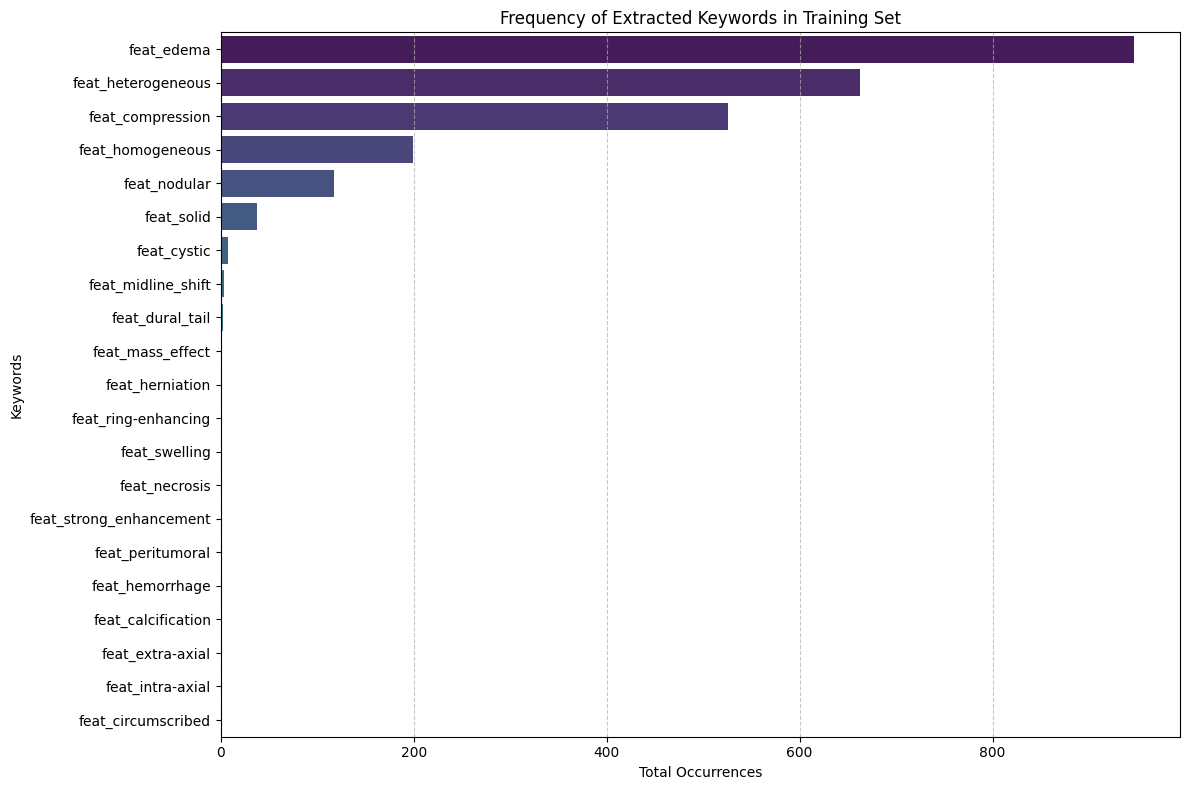

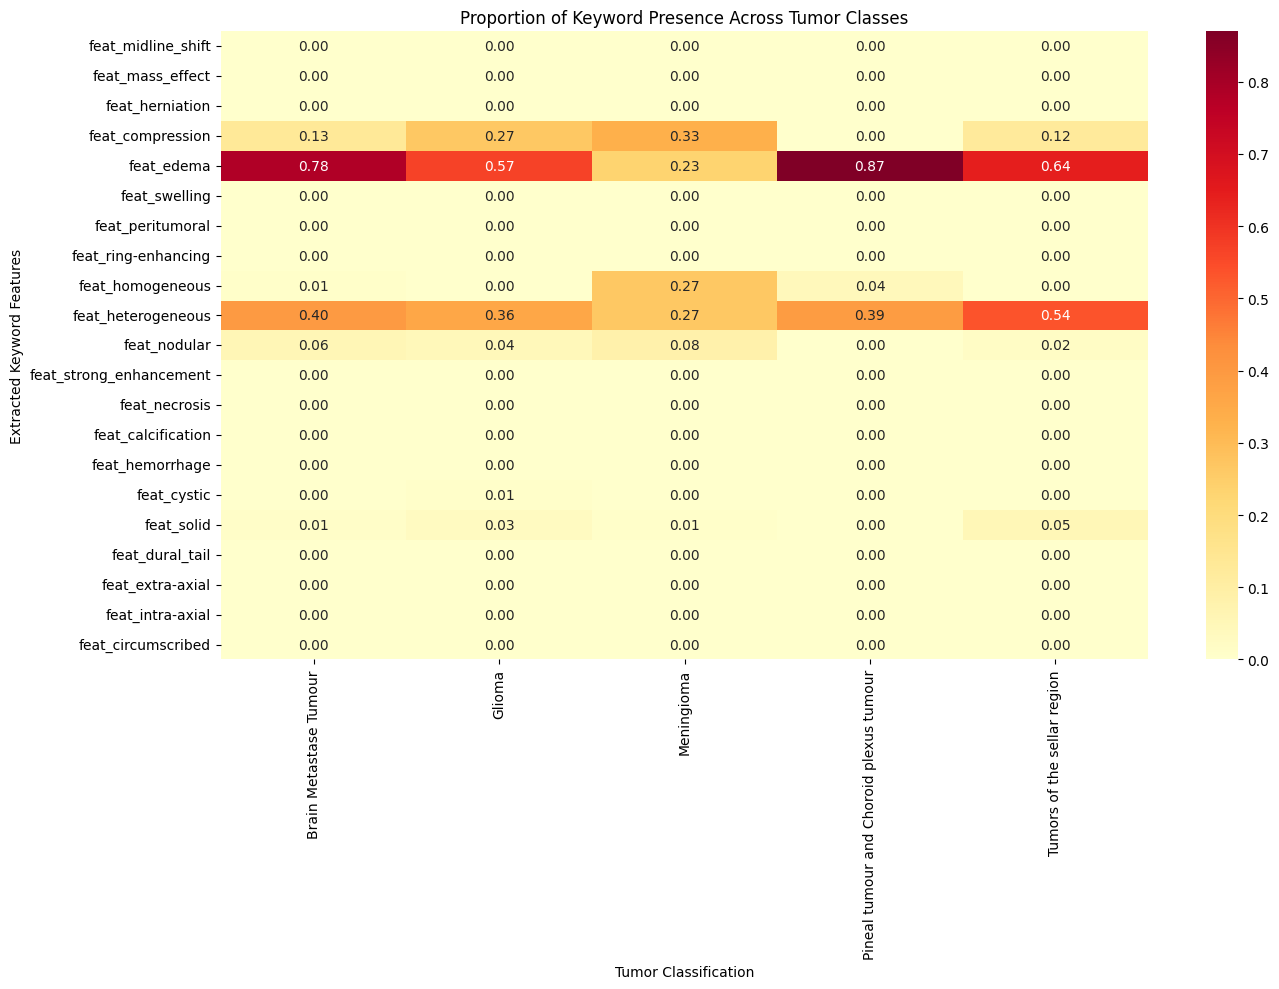


Statistical Correlation Analysis (Keywords vs. Tumor Class):


,Feature,Chi2_Stat,p_value,Significant (p<0.05)
3,feat_homogeneous,352.131524,6.077790e-75,True
2,feat_edema,319.912872,5.476599e-68,True
1,feat_compression,52.781653,9.467054e-11,True
4,feat_heterogeneous,32.180322,1.757430e-06,True
7,feat_solid,14.855056,5.011477e-03,True
5,feat_nodular,14.823141,5.082449e-03,True
6,feat_cystic,8.051148,8.972245e-02,False
8,feat_dural_tail,3.451283,4.853244e-01,False
0,feat_midline_shift,3.443521,4.865179e-01,False


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display

%matplotlib inline

# Ensure the labels are present for analysis
if 'Overall_class' not in df_train.columns:
    print("Warning: Overall_class not found in df_train. Statistical analysis may be limited.")

# Define keyword columns
keyword_cols = [col for col in df_train.columns if col.startswith('feat_')]

# 1. Frequency Distribution (Sanity Check)
keyword_counts = df_train[keyword_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=keyword_counts.values, y=keyword_counts.index, hue=keyword_counts.index, palette="viridis", legend=False)
plt.title("Frequency of Extracted Keywords in Training Set")
plt.xlabel("Total Occurrences")
plt.ylabel("Keywords")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Proportion of Keyword Presence per Tumor Class
# This shows which keywords are most characteristic of specific tumors
class_keyword_dist = df_train.groupby('Overall_class')[keyword_cols].mean()

plt.figure(figsize=(14, 10))
sns.heatmap(class_keyword_dist.T, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Proportion of Keyword Presence Across Tumor Classes")
plt.xlabel("Tumor Classification")
plt.ylabel("Extracted Keyword Features")
plt.tight_layout()
plt.show()

# 3. Statistical Significance (Chi-Square Test)
chi2_results = []
for col in keyword_cols:
    contingency_table = pd.crosstab(df_train[col], df_train['Overall_class'])
    if contingency_table.shape[0] < 2:
        continue
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({'Feature': col, 'Chi2_Stat': chi2, 'p_value': p})

chi2_df = pd.DataFrame(chi2_results).sort_values(by='p_value')
chi2_df['Significant (p<0.05)'] = chi2_df['p_value'] < 0.05

print("\nStatistical Correlation Analysis (Keywords vs. Tumor Class):")
display(chi2_df)

* High-Impact Features: feat_homogeneous and feat_edema are the most powerful predictors, showing extremely low p-values ($< 10^{-67}$). This suggests these clinical descriptions are highly specific to certain tumor types (e.g., Meningioma often appears homogeneous).
* Significant Structural Indicators: feat_compression and feat_heterogeneous also show strong statistical significance ($p < 0.05$), confirming that mass effect and internal texture descriptions are crucial for the model.
* Insignificant Features: Features like feat_dural_tail and feat_midline_shift currently show $p > 0.05$. This might be due to low frequency in the training set rather than a lack of clinical relevance.